# **IMPORT LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **Feature engineering**

In [6]:
df = pd.read_csv("../Data/Delivery_Logistics_reconstructed.csv")

In [7]:
df["order_ts_recon"] = pd.to_datetime(
    df["order_ts_recon"],
    format="%d-%m-%Y %H.%M"
)

df["expected_ts_recon"] = pd.to_datetime(
    df["expected_ts_recon"],
    format="%d-%m-%Y %H.%M"
)

df["delivery_ts_recon"] = pd.to_datetime(
    df["delivery_ts_recon"],
    errors="coerce"
)

In [8]:
print(df["order_ts_recon"].head())
print(df["order_ts_recon"].dtype)

0   2024-10-21 13:00:00
1   2024-01-02 12:00:00
2   2024-05-31 11:00:00
3   2024-01-03 17:00:00
4   2024-03-19 13:00:00
Name: order_ts_recon, dtype: datetime64[ns]
datetime64[ns]


**Time-Based Features**

In [9]:
# Extract day of week (0 = Monday, 6 = Sunday)
df["order_dayofweek"] = df["order_ts_recon"].dt.dayofweek

# Extract day name (Monday, Tuesday, etc.)
df["order_day_name"] = df["order_ts_recon"].dt.day_name()

# Extract month number (1 = January, 12 = December)
# Useful for seasonal analysis (festive rush, monsoon, etc.)
df["order_month"] = df["order_ts_recon"].dt.month

# Extract year (in case dataset spans multiple years)
df["order_year"] = df["order_ts_recon"].dt.year

# Extract hour of the day (0–23)
# Important for traffic and delivery timing patterns
df["order_hour"] = df["order_ts_recon"].dt.hour

**TRAFFIC / BEHAVIORAL FLAGS**

In [10]:
# Weekend flag
# 1 = Saturday or Sunday
# 0 = Weekday
df["is_weekend"] = (df["order_dayofweek"] >= 5).astype(int)


# Rush hour flag
# Morning rush: 8–10 AM
# Evening rush: 5–7 PM
# 1 = Rush hour, 0 = Normal hour
df["rush_hour_flag"] = df["order_hour"].isin(
    [8, 9, 10, 17, 18, 19]
).astype(int)


# Night delivery flag
# 1 = Between 10 PM–5 AM
# Night deliveries may be faster (less traffic) or riskier
df["night_delivery_flag"] = df["order_hour"].isin(
    list(range(0, 6)) + list(range(22, 24))
).astype(int)

In [11]:
df[[
    "order_ts_recon",
    "order_dayofweek",
    "order_day_name",
    "order_month",
    "order_year",
    "order_hour",
    "is_weekend",
    "rush_hour_flag",
    "night_delivery_flag"
]].head()

,order_ts_recon,order_dayofweek,order_day_name,order_month,order_year,order_hour,is_weekend,rush_hour_flag,night_delivery_flag
0,2024-10-21 13:00:00,0,Monday,10,2024,13,0,0,0
1,2024-01-02 12:00:00,1,Tuesday,1,2024,12,0,0,0
2,2024-05-31 11:00:00,4,Friday,5,2024,11,0,0,0
3,2024-01-03 17:00:00,2,Wednesday,1,2024,17,0,1,0
4,2024-03-19 13:00:00,1,Tuesday,3,2024,13,0,0,0


In [12]:
df["order_day_name"].value_counts()

order_day_name
Monday       3588
Tuesday      3588
Friday       3588
Wednesday    3588
Thursday     3588
Saturday     3541
Sunday       3519
Name: count, dtype: int64

In [13]:
df["is_weekend"].value_counts()

is_weekend
0    17940
1     7060
Name: count, dtype: int64

In [14]:
df["rush_hour_flag"].value_counts()

rush_hour_flag
0    15418
1     9582
Name: count, dtype: int64

In [15]:
df["night_delivery_flag"].value_counts()

night_delivery_flag
0    25000
Name: count, dtype: int64

In [16]:
df[[
    "order_dayofweek",
    "order_month",
    "order_hour"
]].describe()

,order_dayofweek,order_month,order_hour
count,25000.000000,25000.000000,25000.000000
mean,2.987960,6.457920,12.515400
std,1.996551,3.423971,2.751564
min,0.000000,1.000000,8.000000
25%,1.000000,3.000000,10.000000
50%,3.000000,6.000000,12.000000
75%,5.000000,9.000000,15.000000
max,6.000000,12.000000,18.000000


In [18]:
df["delayed_flag"] = (df["delayed"] == "yes").astype(int)

delay_by_day = df.groupby("order_day_name")["delayed_flag"].mean()

print(delay_by_day)

order_day_name
Friday       0.247213
Monday       0.267559
Saturday     0.271110
Sunday       0.264848
Thursday     0.272297
Tuesday      0.262263
Wednesday    0.282051
Name: delayed_flag, dtype: float64


In [21]:
df["delayed_flag"] = (df["delayed"] == "yes").astype(int)

weekend_delay = df.groupby("is_weekend")["delayed_flag"].mean()

print(weekend_delay)

is_weekend
0    0.266276
1    0.267989
Name: delayed_flag, dtype: float64


In [23]:
df["delayed_flag"] = (df["delayed"] == "yes").astype(int)

rush_hour_delay = df.groupby("rush_hour_flag")["delayed_flag"].mean()

print(rush_hour_delay)

rush_hour_flag
0    0.218770
1    0.343978
Name: delayed_flag, dtype: float64


In [24]:
df["delayed_flag"] = (df["delayed"] == "yes").astype(int)

night_delay = df.groupby("night_delivery_flag")["delayed_flag"].mean()

print(night_delay)

night_delivery_flag
0    0.26676
Name: delayed_flag, dtype: float64


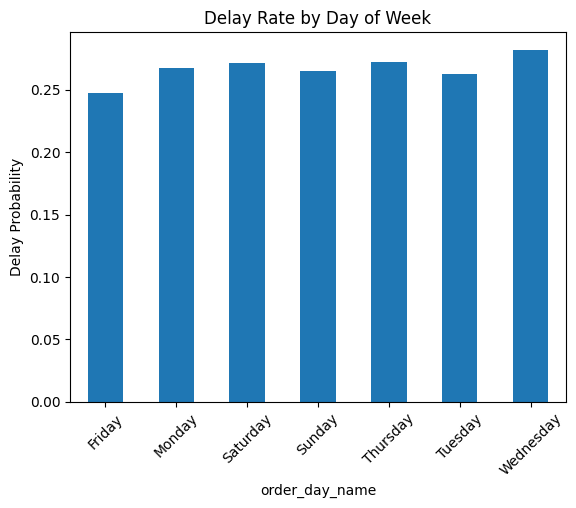

In [26]:
import matplotlib.pyplot as plt

df.groupby("order_day_name")["delayed_flag"].mean().plot(kind="bar")

plt.title("Delay Rate by Day of Week")
plt.ylabel("Delay Probability")
plt.xticks(rotation=45)

plt.show()

**Delay Severity Features**

In [27]:
# -------------------------------
# DELAY SEVERITY CATEGORIZATION
# -------------------------------

def delay_bucket(x):
    if x <= 0:
        return "OnTime/Early"
    elif x <= 2:
        return "Slight Delay"
    elif x <= 6:
        return "Moderate Delay"
    else:
        return "Severe Delay"

# Create multi-class delay severity feature
df["delay_severity"] = df["delay_hours_recon"].apply(delay_bucket)

# Preview output
df[["delay_hours_recon", "delay_severity"]].head()

,delay_hours_recon,delay_severity
0,-43.467511,OnTime/Early
1,-3.870065,OnTime/Early
2,-18.972602,OnTime/Early
3,-44.002989,OnTime/Early
4,-45.866649,OnTime/Early


In [28]:
# -------------------------------
# SEVERE DELAY BINARY FLAG
# -------------------------------

# 1 = Delay more than 6 hours
# 0 = Otherwise
df["severe_delay_flag"] = (df["delay_hours_recon"] > 6).astype(int)

# Check distribution
df["severe_delay_flag"].value_counts()

severe_delay_flag
0    25000
Name: count, dtype: int64

**Distance + Time Efficiency Features**

In [29]:
# -------------------------------
# SPEED CATEGORY BINNING
# -------------------------------

df["speed_category"] = pd.cut(
    df["speed_kmph_recon"],
    bins=[0, 20, 40, 60, 100],
    labels=["Slow", "Medium", "Fast", "Very Fast"]
)

# Preview
df[["speed_kmph_recon", "speed_category"]].head()

,speed_kmph_recon,speed_category
0,30,Medium
1,35,Medium
2,45,Fast
3,30,Medium
4,40,Medium


In [30]:
# -------------------------------
# DELIVERY EFFICIENCY SCORE
# -------------------------------

# Higher speed and lower weather multiplier = better efficiency
df["efficiency_score"] = (
    df["speed_kmph_recon"] / df["weather_mult_recon"]
)

# Summary
df["efficiency_score"].describe()

count    25000.000000
mean        36.459488
std          6.296361
min         25.000000
25%         31.818182
50%         36.363636
75%         40.909091
max         50.000000
Name: efficiency_score, dtype: float64

**Cost & Profitability Features**

In [31]:
# -------------------------------
# COST PER KM
# -------------------------------

df["cost_per_km"] = df["delivery_cost"] / df["distance_km"]

df[["delivery_cost", "distance_km", "cost_per_km"]].head()

,delivery_cost,distance_km,cost_per_km
0,1322.21,235.6,5.612097
1,595.53,81.8,7.280318
2,1608.49,282.9,5.685719
3,469.01,88.6,5.293567
4,1045.27,204.2,5.118854


In [32]:
# -------------------------------
# COST PER KG
# -------------------------------

df["cost_per_kg"] = df["delivery_cost"] / df["package_weight_kg"]

df[["delivery_cost", "package_weight_kg", "cost_per_kg"]].head()

,delivery_cost,package_weight_kg,cost_per_kg
0,1322.21,48.07,27.505929
1,595.53,45.51,13.085695
2,1608.49,31.33,51.340249
3,469.01,8.67,54.095732
4,1045.27,8.09,129.205192


In [33]:
# -------------------------------
# HEAVY PACKAGE FLAG
# -------------------------------

# 1 = weight > 30kg
df["heavy_flag"] = (df["package_weight_kg"] > 30).astype(int)

df["heavy_flag"].value_counts()

heavy_flag
0    14997
1    10003
Name: count, dtype: int64

**Partner & Region Reliability Features**

In [34]:
# -------------------------------
# PARTNER HISTORICAL DELAY RATE
# -------------------------------
# NOTE: Used for EDA/exploration here.
# In model building, delay rates are recomputed on TRAIN only to prevent leakage.

df["partner_delay_rate"] = df.groupby("delivery_partner")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

# Preview
df[["delivery_partner", "partner_delay_rate"]].head()


,delivery_partner,partner_delay_rate
0,amazon logistics,0.272224
1,amazon logistics,0.272224
2,amazon logistics,0.272224
3,amazon logistics,0.272224
4,amazon logistics,0.272224


In [35]:
# -------------------------------
# REGION HISTORICAL DELAY RATE
# -------------------------------

df["region_delay_rate"] = df.groupby("region")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

df[["region", "region_delay_rate"]].head()


,region,region_delay_rate
0,west,0.269480
1,central,0.272530
2,north,0.265710
3,central,0.272530
4,east,0.257979


In [36]:
# -------------------------------
# VEHICLE TYPE DELAY RATE
# -------------------------------

df["vehicle_delay_rate"] = df.groupby("vehicle_type")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

df[["vehicle_type", "vehicle_delay_rate"]].head()


,vehicle_type,vehicle_delay_rate
0,ev bike,0.264343
1,bike,0.270433
2,van,0.267733
3,ev bike,0.264343
4,ev van,0.266278


In [37]:
# -------------------------------
# DELIVERY MODE DELAY RATE
# -------------------------------

df["mode_delay_rate"] = df.groupby("delivery_mode")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

df[["delivery_mode", "mode_delay_rate"]].head()


,delivery_mode,mode_delay_rate
0,standard,0.000000
1,express,0.737847
2,same day,0.325370
3,two day,0.004284
4,two day,0.004284


**Weather-Based Risk Features**

In [38]:
# -------------------------------
# BAD WEATHER FLAG
# -------------------------------

# 1 = Risky weather conditions
# 0 = Normal weather
df["bad_weather_flag"] = df["weather_condition"].isin(
    ["rainy", "stormy", "foggy"]
).astype(int)

# Check distribution
df["bad_weather_flag"].value_counts()

bad_weather_flag
1    12588
0    12412
Name: count, dtype: int64

In [39]:
# -------------------------------
# WEATHER SEVERITY SCORE
# -------------------------------

# Assign severity scores manually
weather_map = {
    "clear": 0,
    "cloudy": 1,
    "hot": 1,
    "cold": 1,
    "rainy": 2,
    "foggy": 3,
    "stormy": 4
}

df["weather_severity"] = df["weather_condition"].map(weather_map)

# Preview
df[["weather_condition", "weather_severity"]].head()

,weather_condition,weather_severity
0,clear,0
1,stormy,4
2,clear,0
3,hot,1
4,rainy,2


In [40]:
# -------------------------------
# WEATHER DISTANCE RISK
# -------------------------------

# Long distance + bad weather = higher delay probability
df["weather_distance_risk"] = (
    df["weather_severity"] * df["distance_km"]
)

df[["weather_severity", "distance_km", "weather_distance_risk"]].head()

,weather_severity,distance_km,weather_distance_risk
0,0,235.6,0.0
1,4,81.8,327.2
2,0,282.9,0.0
3,1,88.6,88.6
4,2,204.2,408.4


**Delivery Status Feature**

In [41]:
# -------------------------------
# DELIVERY STATUS FLAG
# -------------------------------

# 1 = Delivered
# 0 = Otherwise
df["status_delivered_flag"] = (
    df["delivery_status"] == "delivered"
).astype(int)

df["status_delivered_flag"].value_counts()

status_delivered_flag
1    18331
0     6669
Name: count, dtype: int64

**Smart Interaction Features**

In [42]:
# -------------------------------
# LOAD INDEX
# -------------------------------

# Heavy + long distance = operational difficulty
df["load_index"] = (
    df["package_weight_kg"] * df["distance_km"]
)

df[["package_weight_kg", "distance_km", "load_index"]].head()

,package_weight_kg,distance_km,load_index
0,48.07,235.6,11325.292
1,45.51,81.8,3722.718
2,31.33,282.9,8863.257
3,8.67,88.6,768.162
4,8.09,204.2,1651.978


In [43]:
# -------------------------------
# COST WEATHER RISK
# -------------------------------

df["cost_weather_risk"] = (
    df["delivery_cost"] * df["weather_mult_recon"]
)

df[["delivery_cost", "weather_mult_recon", "cost_weather_risk"]].head()

,delivery_cost,weather_mult_recon,cost_weather_risk
0,1322.21,1.0,1322.210
1,595.53,1.1,655.083
2,1608.49,1.0,1608.490
3,469.01,1.1,515.911
4,1045.27,1.2,1254.324


In [44]:
# -------------------------------
# PARTNER WEATHER RISK
# -------------------------------

df["partner_weather_risk"] = (
    df["partner_delay_rate"] * df["weather_severity"]
)

df[[
    "partner_delay_rate",
    "weather_severity",
    "partner_weather_risk"
]].head()

,partner_delay_rate,weather_severity,partner_weather_risk
0,0.272224,0,0.000000
1,0.272224,4,1.088897
2,0.272224,0,0.000000
3,0.272224,1,0.272224
4,0.272224,2,0.544449


**Expected vs Actual Time Features**

In [45]:
# -------------------------------
# TIME RATIO FEATURE
# -------------------------------

# >1 means delayed
# <1 means early
df["time_ratio"] = (
    df["delivery_time_hours_recon"] /
    df["expected_time_hours_recon"]
)

df[[
    "delivery_time_hours_recon",
    "expected_time_hours_recon",
    "time_ratio"
]].head()

,delivery_time_hours_recon,expected_time_hours_recon,time_ratio
0,9.332489,52.8,0.176752
1,4.129935,8.0,0.516242
2,7.427398,26.4,0.281341
3,3.997011,48.0,0.083271
4,6.933351,52.8,0.131313


In [46]:
# -------------------------------
# EARLY DELIVERY FLAG
# -------------------------------

# 1 = Delivered earlier than expected
df["early_flag"] = (
    df["delay_hours_recon"] < 0
).astype(int)

df["early_flag"].value_counts()

early_flag
1    24265
0      735
Name: count, dtype: int64

In [49]:
# ----------------------------------------
# SAVE FULL FEATURE ENGINEERED DATASET
# ----------------------------------------

df.to_csv("../Data/eta_feature_engineered_dataset.csv", index=False)

print("Feature engineered dataset saved successfully!")
print("Total columns:", len(df.columns))

Feature engineered dataset saved successfully!
Total columns: 54
